# Problem: quantum

Two tracks that fail in **opposite** ways: hydrogen, where the law is so
nearly exact that *its own failure* is visible, and the CMB, where the law is
transcendental and the observed band cannot identify it.

In [1]:
import json, warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import HTML, display
from physprior.viz import plots as P
from physprior.io import load_table, load_json
from physprior.config import get_settings
from physprior.benchmark.protocol import fit_arm

RESULTS = get_settings().results_dir
P.use_style()
pd.set_option("display.width", 160, "display.max_columns", 60)

def gif(path, width=560, caption=""):
    "Show an animation from figures/ without embedding it in the notebook."
    cap = f"<div style='color:#52514e;font-size:90%'>{caption}</div>" if caption else ""
    return HTML(f"<img src='../figures/{path}' width='{width}'>{cap}")

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


## 1 · The problem — one equation, two very different tracks

Everything here comes from the time-independent Schrödinger equation,

$$-\tfrac{1}{2}\psi''(x) + V(x)\,\psi(x) = E\,\psi(x)$$

**Hydrogen.** Bohr's law says the levels go as $-1/n^{2}$:

$$E_{n} = -\frac{R_{H}}{n^{2}}$$

It is very nearly right, and the interesting question is *how* it is wrong —
relativistic and QED corrections shift the 1s level by about 10 ppm, and NIST
measures the levels far more precisely than that.

**The CMB.** Planck's law is transcendental:

$$B_{\nu}(T) = \frac{2h\nu^{3}}{c^{2}}
\frac{1}{e^{h\nu/kT} - 1}$$

Over the band FIRAS actually observed, $x = h\nu/kT$ runs from 1.2 to 11.3 —
almost all Wien — and there $e^{-x}$ and $1/(e^{x}-1)$ are nearly the same
function. **The denominator is not identifiable from the data.** That is the
whole track.

## 2 · The data — created, then pulled

### 2a · Created — and the solver's error is measured, not assumed

In [2]:
m = load_json("quantum", "problem_meta")
sp = m["simulations"]["spectra"]
rows = [{"system": k, "law": v["law"], "max rel error": v["max_rel_error"],
         "E_0": v["energy"][0], "E_0 exact": v["exact"][0]} for k,v in sp.items()]
display(pd.DataFrame(rows))

,system,law,max rel error,E_0,E_0 exact
0,harmonic,E_n = (n + 1/2) omega,0.000010,0.499999,0.500000
1,hydrogen,E_n = -1/(2 n^2) Hartree,0.000130,-0.499935,-0.500000
2,infinite_well,E_n = n^2 pi^2 / (2 L^2),0.000005,4.934802,4.934802


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(11.0, 3.2))
for ax, name in zip(axes, ["infinite_well","harmonic","hydrogen"]):
    display(gif(f"quantum/eigenstates_{name}.png", 340))
plt.close(fig)

**Richardson extrapolation, because the solver was coarser than the effect.**
Plain second-order differences give the hydrogen levels to ~300 ppm. The QED
shift is 10.8 ppm. A solver 30× less accurate than the effect cannot see it,
and differencing anyway would report discretisation error as physics.

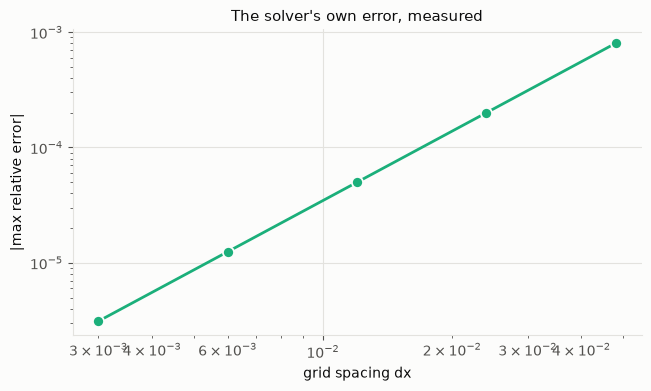

,max_rel_err_n160000,max_rel_err_n40000,max_rel_err_n80000,r_min
0,0.000012,0.000130,0.000036,0.000001
1,0.000048,0.000166,0.000071,0.000010
2,0.000405,0.000517,0.000427,0.000100
3,0.003933,0.003995,0.003939,0.001000


the r_min sweep is the companion warning: refine dx all you like,
the inner boundary sets the floor


In [4]:
gc = pd.DataFrame(m["simulations"]["grid_convergence"])
fig, ax = plt.subplots(figsize=(6.4,3.8))
ax.loglog(gc.dx, gc.max_rel_error.abs(), "o-", color=P.ARM_COLOR["pinn"], markersize=8,
          markeredgecolor=P.SURFACE, markeredgewidth=1.3)
ax.set_xlabel("grid spacing dx"); ax.set_ylabel("|max relative error|")
ax.set_title("The solver's own error, measured")
plt.show()
display(pd.DataFrame(m["simulations"]["r_min_sweep"]))
print("the r_min sweep is the companion warning: refine dx all you like,")
print("the inner boundary sets the floor")

In [5]:
tu = m["simulations"]["tunnelling"]
display(gif("quantum/tunnelling.gif", 640))
print(f"packet energy   : {tu['energy']:.3f}")
print(f"barrier height  : {tu['barrier_height']:.3f}")
print(f"norm conserved to {tu['norm_drift']:.1e} -- unitary by construction")

packet energy   : 0.980
barrier height  : 1.200
norm conserved to 5.4e-15 -- unitary by construction


### 2b · Pulled — NIST hydrogen levels, and the COBE/FIRAS monopole

NIST H I : 40 levels
FIRAS    : 43 channels, 68-639 GHz  (turnover at 160)
caveat   : the distributed monopole = 2.725 K blackbody + measured residual, so T recovery is partly by construction


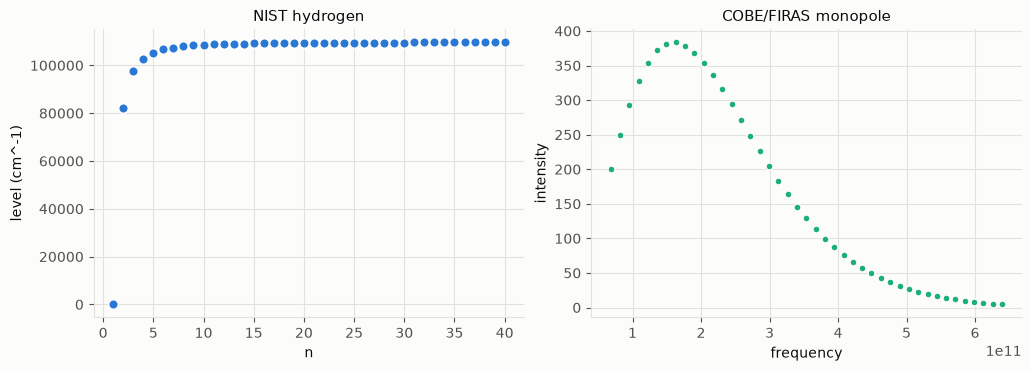

In [6]:
from physprior.problems.quantum import cmb, hydrogen
prob, hmeta = hydrogen.problem()
hmeta = {**hmeta, **load_json("quantum/hydrogen", "meta")}
cprob, cmeta = cmb.problem()
cmeta = {**cmeta, **load_json("quantum/cmb", "meta")}
print(f"NIST H I : {len(prob)} levels")
print(f"FIRAS    : {len(cprob)} channels, {cmeta['nu_ghz_range'][0]:.0f}-"
      f"{cmeta['nu_ghz_range'][1]:.0f} GHz  (turnover at {cmeta['turnover_ghz']:.0f})")
print(f"caveat   : {cmeta['caveat']}")

fig, axes = plt.subplots(1, 2, figsize=(10.2, 3.6))
axes[0].plot(prob.x[:,0], prob.y, "o", color=P.ARM_COLOR["physics"], markersize=7,
             markeredgecolor=P.SURFACE, markeredgewidth=1.2)
axes[0].set_xlabel("n"); axes[0].set_ylabel("level (cm^-1)"); axes[0].set_title("NIST hydrogen")
axes[1].plot(cprob.x[:,0], cprob.y, "o", color=P.ARM_COLOR["pinn"], markersize=5,
             markeredgecolor=P.SURFACE, markeredgewidth=1.0)
axes[1].set_xlabel("frequency"); axes[1].set_ylabel("intensity")
axes[1].set_title("COBE/FIRAS monopole")
plt.show()

## 3 · The method

Two different jobs travel under the name *physics-informed*, and this track does the following:

1. **Discovery** — find a law nobody supplied. Only `sr` (symbolic regression) can do this; it is given numbers and an operator set, never an equation.

2. **Recovery** — measure a constant *inside* a law that is supplied. `physics` fits it classically with a covariance; `pinn` fits it with a neural correction alongside, and `w_phys` sets how much correction is allowed.

**Arms run here:** `oracle` · `physics` · `pinn` · `sr` · `nn`

Both jobs, and this is the track where the difference bites hardest. Discovery runs on the **solved spectra**, where the law is known, and succeeds: symbolic regression finds `n^2`, `(n + 1/2)` and `-1/n^2`. On **FIRAS** the same machinery fails to find Planck's law and returns a Wien-like exponential instead — and that negative result is reported at the same size as the successes, with the control that isolates its cause.

Both laws are algebraic, so both `pinn` arms are the **law + correction** form — panel B.

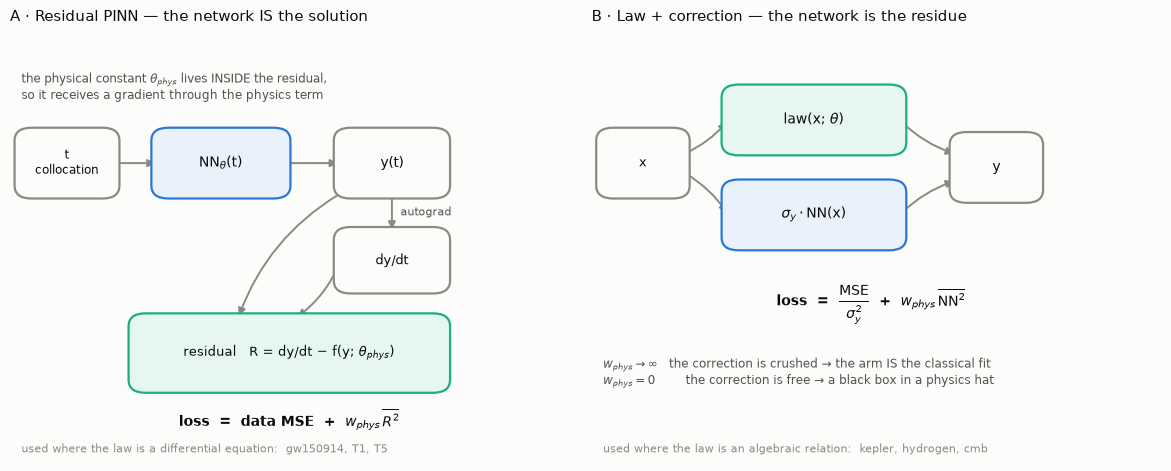

In [7]:
P.fig_pinn_anatomy(); plt.show()

## 4 · The results — discovery on the simulation, recovery on the real thing

In [8]:
display(load_table("quantum","spectrum_laws"))
for r in m["discovery"]["spectrum_laws"]:
    print(f"[{r['system']:9s}] {r['law']}")
    print(f"    SR: {r['sr_expression']}")

,system,law,n_levels,solver_max_rel_error,sr_expression,scale,exponent_found,exponent_expected,exponent_error,level_spacing,level_spacing_std
0,well,E_n = n^2 pi^2 / (2 L^2),10,0.000005,(n**2 - 5.1084587e-8*(n**4 - n))*0.010000051,493.477682,1.999998,2.0,0.000002,54.282542,25.482940
1,harmonic,E_n = (n + 1/2) omega,10,0.000010,n*(0.10526405 + n*(-1.0496476e-7)) + 0.052632026,9.499909,NaN,NaN,NaN,0.999990,0.000005
2,hydrogen,E_n = -1/(2 n^2) Hartree,10,0.000130,-1.0001295/(n**2 + 0.00012947575),0.499935,-1.999944,-2.0,0.000056,0.054993,0.114969


[well     ] E_n = n^2 pi^2 / (2 L^2)
    SR: (n**2 - 5.1084587e-8*(n**4 - n))*0.010000051
[harmonic ] E_n = (n + 1/2) omega
    SR: n*(0.10526405 + n*(-1.0496476e-7)) + 0.052632026
[hydrogen ] E_n = -1/(2 n^2) Hartree
    SR: -1.0001295/(n**2 + 0.00012947575)


### Hydrogen: the law's own failure, from two directions

In [9]:
f = fit_arm("physics", prob, np.arange(len(prob)), seed=11)
print(f"R fitted from the levels : {f.params['R']:.4f} cm^-1")
print(f"Bohr's prediction        : {hmeta['bohr_rydberg_H_icm']:.4f} cm^-1")
print(f"gap                      : {hmeta['limit_minus_bohr_ppm']:.2f} ppm  = QED + relativistic")
display(gif("quantum/hydrogen/bohr_residual.png", 600))

R fitted from the levels : 109678.7774 cm^-1
Bohr's prediction        : 109677.5834 cm^-1
gap                      : 10.83 ppm  = QED + relativistic


In [10]:
sv = m["discovery"]["schrodinger_vs_nist"]
print(f"solver error        : {sv['solver_max_rel_error_ppm']:.1f} ppm "
      f"(plain finite differences: {sv['solver_without_richardson_ppm']:.0f} ppm)")
print(f"simulation vs NIST  : {sv['mean_gap_ppm']:+.1f} ppm (mean over n)")
print("the same QED shift, reached by solving the equation rather than fitting the law")

solver error        : 4.0 ppm (plain finite differences: 43 ppm)
simulation vs NIST  : +15.4 ppm (mean over n)
the same QED shift, reached by solving the equation rather than fitting the law


### The CMB: where fitting well and finding the law come apart

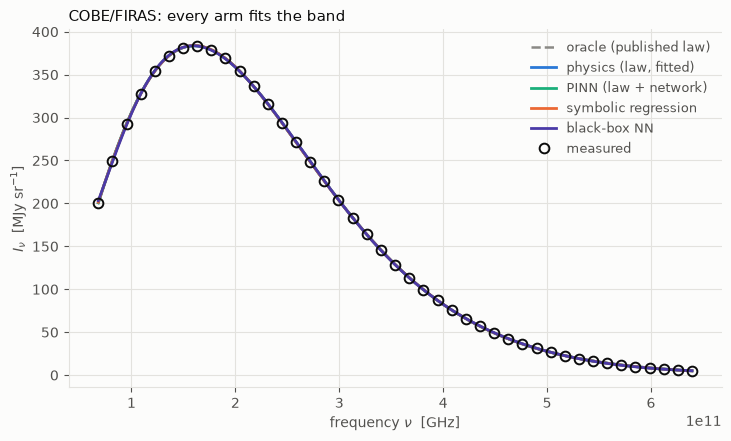

SR expression: (nu + 0.07698194291844*(1.3383667 - nu)**2)**3*exp((1.5615451 - nu)/0.5149329)


In [11]:
cfits = {a: fit_arm(a, cprob, np.arange(len(cprob)), seed=11)
         for a in ["oracle","physics","pinn","sr","nn"]}
P.fig_overview(cprob, cfits, title="COBE/FIRAS: every arm fits the band")
plt.show()
print("SR expression:", cfits["sr"].expression)

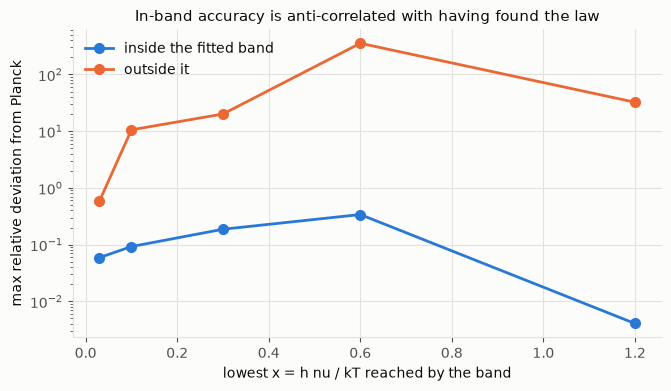

In [12]:
ctrl = pd.DataFrame(json.load(open(RESULTS / "_band_control.json")))
display(gif("quantum/cmb/band_coverage_control.png", 600))
fig, ax = plt.subplots(figsize=(6.6,3.8))
ax.semilogy(ctrl.x_min, ctrl.max_rel_dev_in_band, "o-", color=P.ARM_COLOR["physics"],
            label="inside the fitted band")
ax.semilogy(ctrl.x_min, ctrl.max_rel_dev_outside, "o-", color=P.ARM_COLOR["sr"],
            label="outside it")
ax.set_xlabel("lowest x = h nu / kT reached by the band")
ax.set_ylabel("max relative deviation from Planck")
ax.set_title("In-band accuracy is anti-correlated with having found the law")
ax.legend(); plt.show()

**Fit quality on the observed range is not evidence that you have discovered
anything.** The FIRAS-coverage run has the *best* in-band fit of the five and
one of the worst extrapolations.

---

## Conclusion

Everything below is rendered from `results/` at execution time by
`physprior.reporting.conclusions` — the verdicts, the margins and the prose.
A gap smaller than the seed-to-seed spread on the reporting seeds
(11 / 23 / 42) is reported as a **tie**, not rounded into a win.

In [13]:
from physprior.reporting import conclusions as C
verdicts = C.verdict_frame('quantum')
display(verdicts)

,track,question,winner,runner-up,margin,seed spread,verdict
0,quantum/hydrogen,interpolation,sr,physics,1.24x,1.1e-06,TIE (within seed spread)
1,quantum/hydrogen,data efficiency,physics,sr,9.19x,5.8e-06,WIN
2,quantum/hydrogen,noise,pinn,physics,8.62x,0.026,TIE (within seed spread)
3,quantum/hydrogen,extrapolation,sr,physics,1.22x,2.8e-07,TIE (within seed spread)
4,quantum/hydrogen,parameter recovery (R),physics,pinn,1.01x,5.5e-06,WIN
5,quantum/cmb,interpolation,physics,pinn,1.02x,9.2e-05,TIE (within seed spread)
6,quantum/cmb,data efficiency,pinn,physics,1.01x,0.00028,TIE (within seed spread)
7,quantum/cmb,noise,pinn,physics,1.1x,0.039,TIE (within seed spread)
8,quantum/cmb,extrapolation,physics,pinn,1.15x,9.9e-05,TIE (within seed spread)
9,quantum/cmb,parameter recovery (T),physics,pinn,1.01x,0.00047,TIE (within seed spread)


In [14]:
from IPython.display import Markdown
display(Markdown(C.conclusion_markdown('quantum')))

Across 10 protocol questions on 2 track(s), **2 produced a decisive answer** and 8 were inside the seed-to-seed spread and are reported as ties rather than rounded into wins. **`physics` takes 2 of the decisive question(s)**. The largest single gap is on **quantum/hydrogen / data efficiency**, where `physics` beats `sr` by **9.19x**. The `pinn` arm — the one this project is built around — wins **0**, loses **2** and ties **8** of these, which is the number to read before any claim about what a physics prior buys. An arm beats the **oracle** out of range (`physics` on quantum/hydrogen by 83.7x; `sr` on quantum/hydrogen by 102x; `physics` on quantum/cmb by 2.01x; `pinn` on quantum/cmb by 1.75x): the oracle carries the *published* constant, so this is a claim about that constant, and the track's `meta.json` records the explanation.

In [15]:
lines = ["- " + line for line in C.what_would_change_this('quantum')]
display(Markdown("**What would change this conclusion**\n\n" + "\n".join(lines)))

**What would change this conclusion**

- `physics` wins 2 question(s) (hydrogen data efficiency; hydrogen parameter recovery (R)): it assumes the published law is right. A track where the law is incomplete — a truncated expansion, a neglected term — removes that advantage, which is exactly what the `pinn` arm exists to test.
- 8 question(s) are ties: more seeds, or a lower-variance fit (ensembling, early stopping), would decide them either way.
- The 9.19x gap on quantum/hydrogen / data efficiency rests on three seeds with a spread of 5.8e-06; it would be overturned by a seed set on which `sr` closes to within that spread, which is why the margin and the spread are printed side by side above.
- The oracle being beaten would be overturned by a revised published constant: the oracle is only as good as the literature value it carries.